Dataset Shape: (12000, 11)

First 5 Rows:
   transaction_amount  transaction_time  distance_from_home_km  \
0               41.49             64643                  45.94   
1               27.51             21750                  28.18   
2               27.06             68670                  12.08   
3                8.13             48809                   4.07   
4               12.40             69536                   5.40   

   merchant_risk_score  device_trust_score  failed_attempts  \
0                0.129               0.833                1   
1                0.331               1.000                1   
2                0.239               0.754                0   
3                0.296               1.000                1   
4                0.120               0.901                0   

   previous_transactions  account_age_days  online_transaction  \
0                     13               391                   0   
1                      6                39        

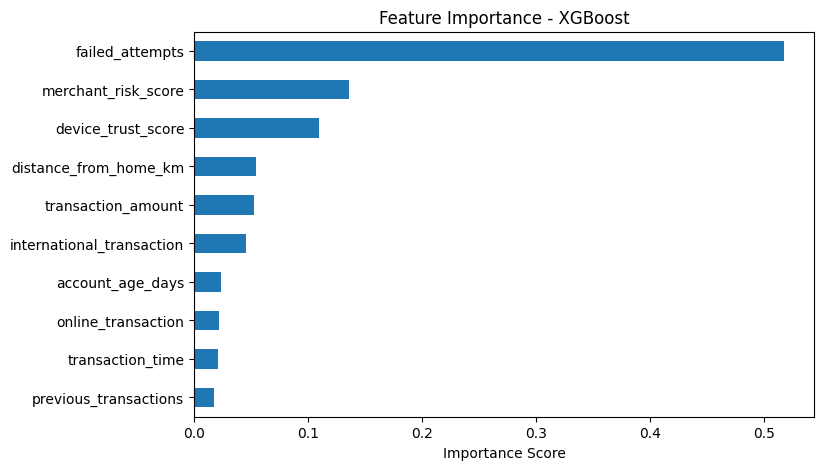

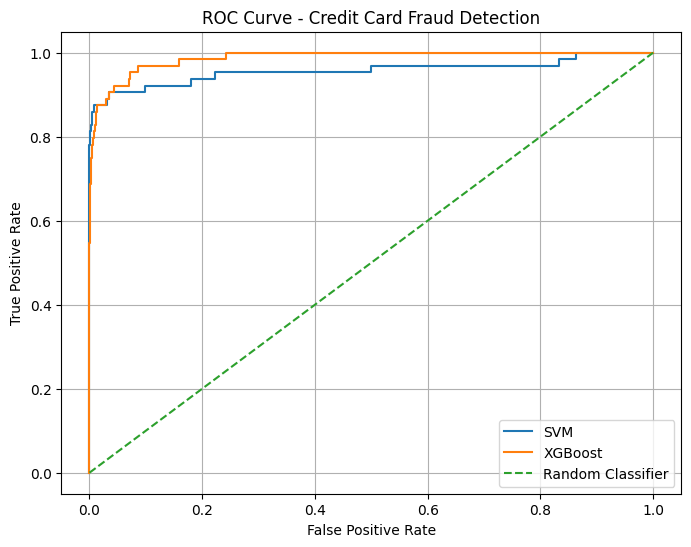


Threshold: 0.4
Precision: 0.5185
Recall: 0.875
F1 Score: 0.6512

========== FEATURE IMPORTANCE ==========
failed_attempts              0.517528
merchant_risk_score          0.136012
device_trust_score           0.109862
distance_from_home_km        0.054560
transaction_amount           0.052819
international_transaction    0.045825
account_age_days             0.023372
online_transaction           0.021872
transaction_time             0.021015
previous_transactions        0.017134
dtype: float32


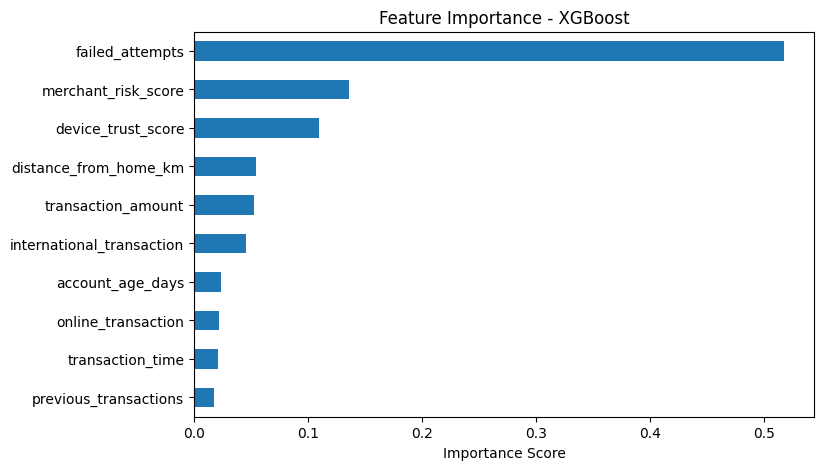

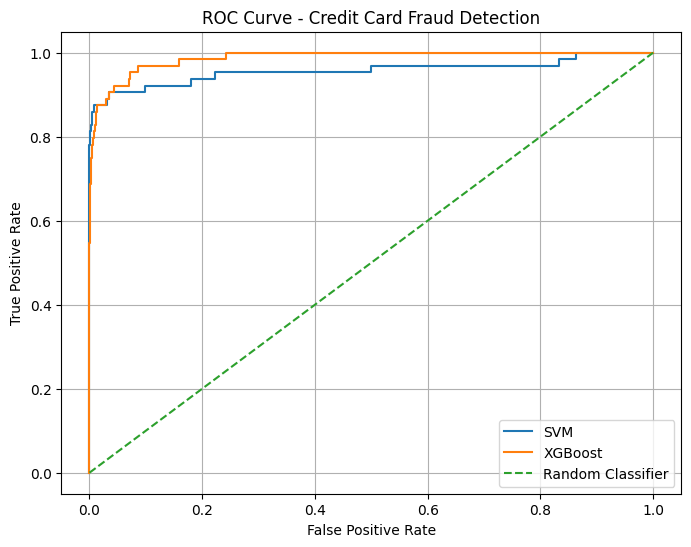


Threshold: 0.3
Precision: 0.4453
Recall: 0.8906
F1 Score: 0.5938

========== FEATURE IMPORTANCE ==========
failed_attempts              0.517528
merchant_risk_score          0.136012
device_trust_score           0.109862
distance_from_home_km        0.054560
transaction_amount           0.052819
international_transaction    0.045825
account_age_days             0.023372
online_transaction           0.021872
transaction_time             0.021015
previous_transactions        0.017134
dtype: float32


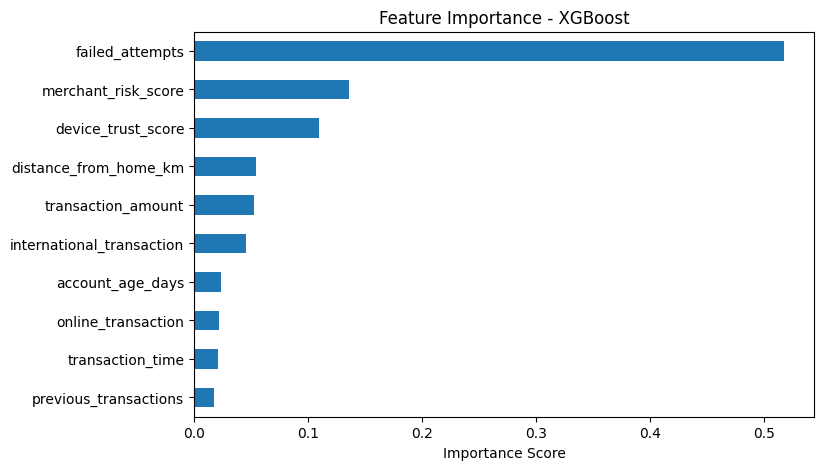

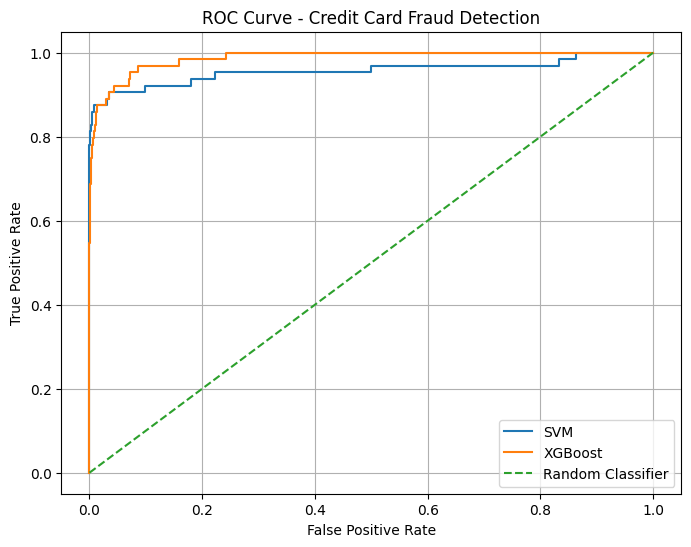


Threshold: 0.2
Precision: 0.3816
Recall: 0.9062
F1 Score: 0.537

========== FEATURE IMPORTANCE ==========
failed_attempts              0.517528
merchant_risk_score          0.136012
device_trust_score           0.109862
distance_from_home_km        0.054560
transaction_amount           0.052819
international_transaction    0.045825
account_age_days             0.023372
online_transaction           0.021872
transaction_time             0.021015
previous_transactions        0.017134
dtype: float32


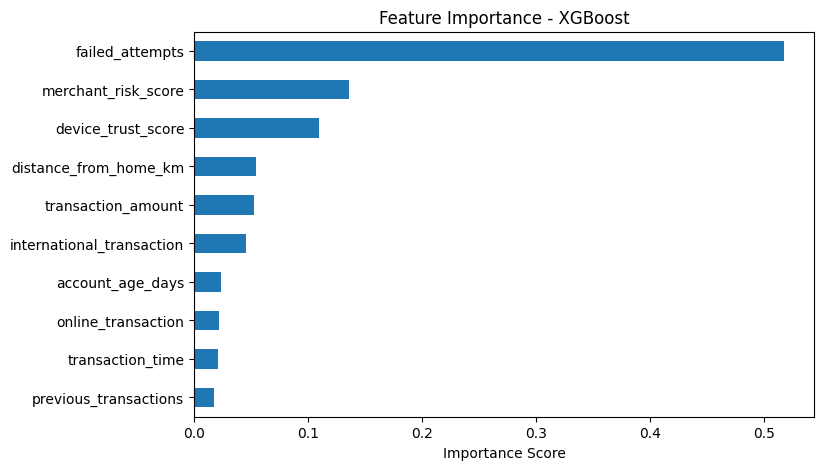

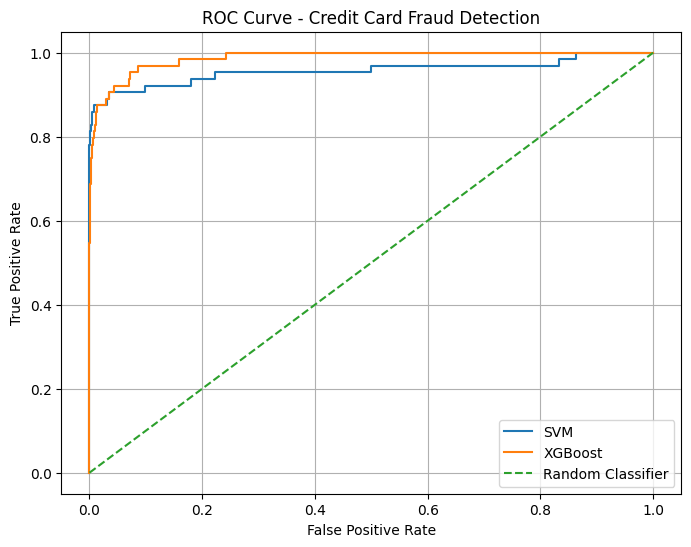

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
        confusion_matrix,
            roc_auc_score,
                roc_curve,
                    precision_score,
                        recall_score,
                            f1_score
                            )
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
df = pd.read_csv("credit_card_fraud_small.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())
print("\nClass Distribution:")
print(df["is_fraud"].value_counts())

print("\nFraud Percentage:")
print(round(df["is_fraud"].mean() * 100, 2), "%")
print("\nClass Distribution:")
print(df["is_fraud"].value_counts())

X = df.drop("is_fraud", axis=1)

y = df["is_fraud"]
X_train, X_test, y_train, y_test = train_test_split(
      X,
      y,
      test_size=0.20,
      random_state=42,
      stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(
    probability=True,
        random_state=42 )

svm.fit(X_train_scaled, y_train)

svm_prob = svm.predict_proba(X_test_scaled)[:, 1]

svm_pred = (svm_prob >= 0.50).astype(int)

print("\n========== SVM BASELINE ==========")

print("ROC-AUC:",
      round(roc_auc_score(y_test, svm_prob), 4))

print("Precision:",
        round(precision_score(y_test, svm_pred, zero_division=0), 4))

print("Recall:",
      round(recall_score(y_test, svm_pred, zero_division=0), 4))

print("F1 Score:",
       round(f1_score(y_test, svm_pred, zero_division=0), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train)

print("\n========== SMOTE ==========")

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())
xgb = XGBClassifier(
      n_estimators=200,
      max_depth=5,
      learning_rate=0.05,
      subsample=0.8,
      colsample_bytree=0.8,
      eval_metric="logloss",
      random_state=42)
xgb.fit(
    X_train_smote,
    y_train_smote
  )
xgb_prob = xgb.predict_proba(X_test)[:, 1]

xgb_pred = (xgb_prob >= 0.50).astype(int)

print("\n========== XGBOOST ==========")

print("ROC-AUC:",
      round(roc_auc_score(y_test, xgb_prob), 4))

print("Precision:",
      round(precision_score(y_test, xgb_pred, zero_division=0), 4))

print("Recall:",
      round(recall_score(y_test, xgb_pred, zero_division=0), 4))

print("F1 Score:",
      round(f1_score(y_test, xgb_pred, zero_division=0), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
print("\n========== THRESHOLD TUNING ==========")

thresholds = [0.50, 0.40, 0.30, 0.20]

for threshold in thresholds:

    prediction = (xgb_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        prediction,
        zero_division=0 )

    recall = recall_score(
          y_test,
          prediction,
          zero_division=0
    )
    f1 = f1_score(
          y_test,
          prediction,
          zero_division=0
    )
    print("\nThreshold:", threshold)
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))

    importance = pd.Series(
        xgb.feature_importances_,
        index=X.columns
            )

    importance = importance.sort_values(
          ascending=False
  )

    print("\n========== FEATURE IMPORTANCE ==========")

    print(importance)
    plt.figure(figsize=(8, 5))

    importance.sort_values().plot(
        kind="barh"
        )

    plt.title("Feature Importance - XGBoost")

    plt.xlabel("Importance Score")

    plt.show()
    svm_fpr, svm_tpr, _ = roc_curve(
          y_test,
          svm_prob
              )
    xgb_fpr, xgb_tpr, _ = roc_curve(
          y_test,
          xgb_prob
              )
    plt.figure(figsize=(8, 6))

    plt.plot(
        svm_fpr,
        svm_tpr,
        label="SVM"
                )
    plt.plot(
          xgb_fpr,
          xgb_tpr,
          label="XGBoost"
                  )
    plt.plot(
          [0, 1],
          [0, 1],
          "--",
          label="Random Classifier"
                      )
    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve - Credit Card Fraud Detection")

    plt.legend()

    plt.grid()

    plt.show()







